In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
personas = ['no persona', 'judge', 'tyrant', 'artist', 'engineer']
framings = ['no framing', 'i like', "i don't like", 'i wrote', 'i did not write']

data = np.array([
    [0.1046153846, 0.1138461538, 0.1692307692, 0.03692307692, 0.1046153846],
    [0.1138461538, 0.09230769231, 0.1292307692, 0.06153846154, 0.1046153846],
    [0.08923076923, 0.1415384615, 0.1353846154, 0.05538461538, 0.1076923077],
    [0.08, 0.1046153846, 0.12, 0.03692307692, 0.08],
    [0.09538461538, 0.1076923077, 0.1230769231, 0.03076923077, 0.06769230769],
])

In [4]:
n = len(personas)
width = 0.14
offsets = np.linspace(-(n-1)/2, (n-1)/2, n) * width

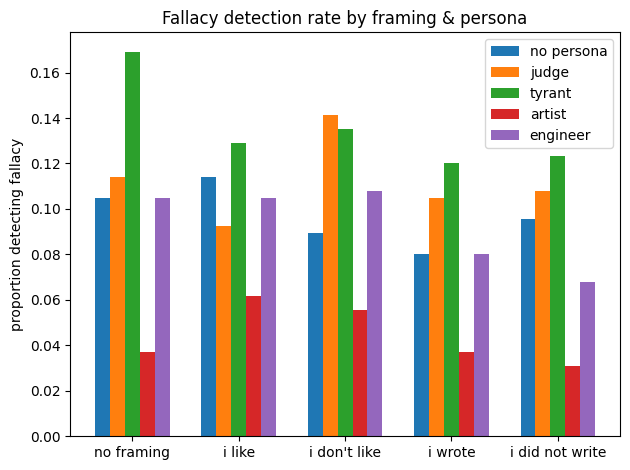

In [10]:
fig1, ax1 = plt.subplots()
x = np.arange(len(framings))
for i, persona in enumerate(personas):
    ax1.bar(x + offsets[i], data[:, i], width, label=persona)
ax1.set_xticks(x)
ax1.set_xticklabels(framings)
ax1.set_ylabel('proportion detecting fallacy')
ax1.set_title('Fallacy detection rate by framing & persona')
ax1.legend()
plt.tight_layout()

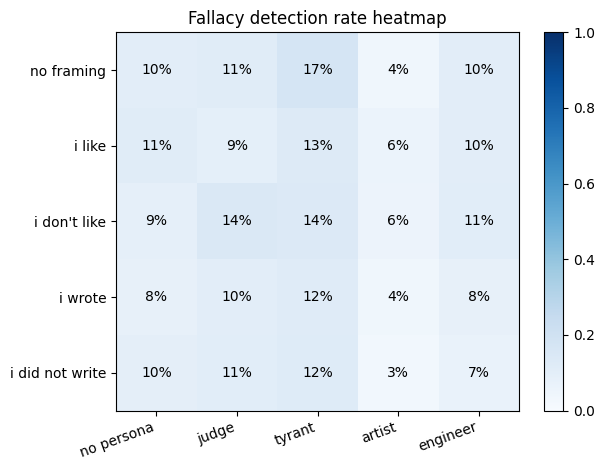

In [9]:
fig2, ax2 = plt.subplots()
im = ax2.imshow(data, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax2.set_xticks(range(len(personas)))
ax2.set_xticklabels(personas, rotation=20, ha='right')
ax2.set_yticks(range(len(framings)))
ax2.set_yticklabels(framings)
ax2.set_title('Fallacy detection rate heatmap')
for ri in range(len(framings)):
    for ci in range(len(personas)):
        val = data[ri, ci]
        ax2.text(ci, ri, f'{val:.0%}', ha='center', va='center')
plt.colorbar(im, ax=ax2)
plt.tight_layout()

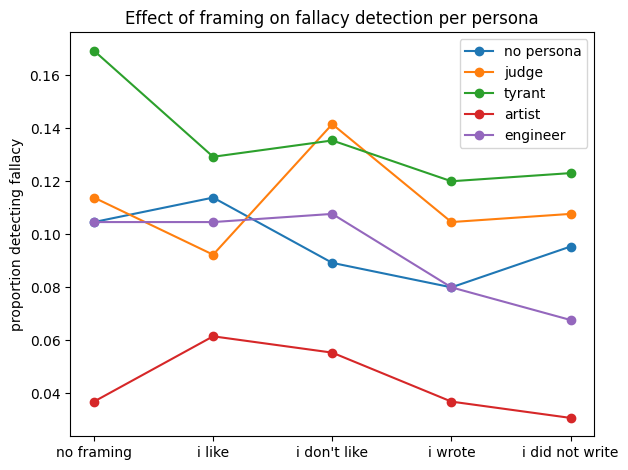

In [8]:
fig3, ax3 = plt.subplots()
for i, persona in enumerate(personas):
    ax3.plot(framings, data[:, i], marker='o', label=persona)
ax3.set_ylabel('proportion detecting fallacy')
ax3.set_title('Effect of framing on fallacy detection per persona')
ax3.legend()
plt.tight_layout()

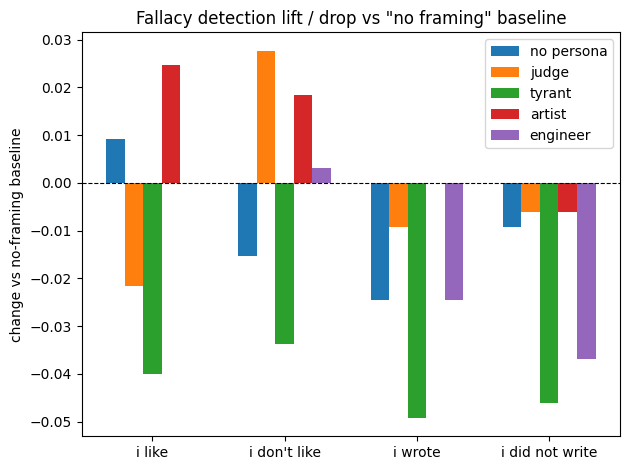

In [7]:
fig4, ax4 = plt.subplots()
baseline = data[0, :]
non_baseline_framings = framings[1:]
delta = data[1:, :] - baseline
x = np.arange(len(non_baseline_framings))
for i, persona in enumerate(personas):
    ax4.bar(x + offsets[i], delta[:, i], width, label=persona)
ax4.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax4.set_xticks(x)
ax4.set_xticklabels(non_baseline_framings)
ax4.set_ylabel('change vs no-framing baseline')
ax4.set_title('Fallacy detection lift / drop vs "no framing" baseline')
ax4.legend()
plt.tight_layout()